# Running Harmonised Earth S1Denoise

J. -W. Park, A. A. Korosov, M. Babiker, S. Sandven and J. -S. Won, "[Efficient Thermal Noise Removal for Sentinel-1 TOPSAR Cross-Polarization Channel](https://ieeexplore.ieee.org/document/9137384)," in IEEE Transactions on Geoscience and Remote Sensing, vol. 56, no. 3, pp. 1555-1565, March 2018, doi: 10.1109/TGRS.2017.2765248.

A. Stokholm, T. Wulf, A. Kucik, R. Saldo, J. Buus-Hinkler and S. M. Hvidegaard, "[AI4SeaIce: Toward Solving Ambiguous SAR Textures in Convolutional Neural Networks for Automatic Sea Ice Concentration Charting](https://ieeexplore.ieee.org/document/9705586)," in IEEE Transactions on Geoscience and Remote Sensing, vol. 60, pp. 1-13, 2022, Art no. 4304013, doi: 10.1109/TGRS.2022.3149323.

F. De Zan and A. Monti Guarnieri, "[TOPSAR: Terrain Observation by Progressive Scans,](https://ieeexplore.ieee.org/document/1677745)" in IEEE Transactions on Geoscience and Remote Sensing, vol. 44, no. 9, pp. 2352-2360, Sept. 2006, doi: 10.1109/TGRS.2006.873853.

Y. Sun and X. -M. Li, "[Denoising Sentinel-1 Extra-Wide Mode Cross-Polarization Images Over Sea Ice,](https://ieeexplore.ieee.org/document/9137384)" in IEEE Transactions on Geoscience and Remote Sensing, vol. 59, no. 3, pp. 2116-2131, March 2021, doi: 10.1109/TGRS.2020.3005831.

[Sentinel-1 TOPSAR](https://asf.alaska.edu/data-sets/sar-data-sets/sentinel-1/sentinel-1-what-is-topsar/)

[GLCM in scipy](https://scikit-image.org/docs/dev/auto_examples/features_detection/plot_glcm.html)

[Entropy from GLCM - stackoverflow](https://stackoverflow.com/questions/40919936/calculating-entropy-from-glcm-of-an-image)

Tutorial for running HarmonizedEarth_s1denoise package

In [1]:
import sys
sys.path.append('..')  #/heS1denoise')

import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from heS1denoise.sentinel1image import S1Image, range_profile_average

Set constants

In [2]:
variance_threshold = 10**-7.1
power_balance_threshold = 0.002

In [3]:
DATAPATH = Path('/media', 'apbarret', 'andypbarrett_work', 'Data', 'Sentinel1_Sun')
IMAGEPATH = DATAPATH / 'S1A_EW_GRDM_1SDH_20180902T165032_20180902T165132_023522_028FAA_35D2.zip'

The image is loaded into the `S1Image` class. This Class is built on top of `s1denoise` and has the same methods and attributes of that class, but also has additional methods for applying Sun's denoising algorithm.  

In [4]:
s1 = S1Image(IMAGEPATH)

04:33:01|40|nansat|_get_dataset_metadata|GDAL could not open /media/apbarret/andypbarrett_work/Data/Sentinel1_Sun/S1A_EW_GRDM_1SDH_20180902T165032_20180902T165132_023522_028FAA_35D2.zip, trying to read with Nansat mappers...


In [5]:
s1

----------------------------------------
/media/apbarret/andypbarrett_work/Data/Sentinel1_Sun/S1A_EW_GRDM_1SDH_20180902T165032_20180902T165132_023522_028FAA_35D2.zip----------------------------------------
Mapper: sentinel1_l1Band : 1 DN_HH
  dataType: 2
  name: DN_HH
  SourceBand: 1
  SourceFilename: /vsizip//media/apbarret/andypbarrett_work/Data/Sentinel1_Sun/S1A_EW_GRDM_1SDH_20180902T165032_20180902T165132_023522_028FAA_35D2.zip/S1A_EW_GRDM_1SDH_20180902T165032_20180902T165132_023522_028FAA_35D2.SAFE/measurement/s1a-ew-grd-hh-20180902t165032-20180902t165132-023522-028faa-001.tiff
Band : 2 DN_HV
  dataType: 2
  name: DN_HV
  SourceBand: 1
  SourceFilename: /vsizip//media/apbarret/andypbarrett_work/Data/Sentinel1_Sun/S1A_EW_GRDM_1SDH_20180902T165032_20180902T165132_023522_028FAA_35D2.zip/S1A_EW_GRDM_1SDH_20180902T165032_20180902T165132_023522_028FAA_35D2.SAFE/measurement/s1a-ew-grd-hv-20180902t165032-20180902t165132-023522-028faa-002.tiff
Band : 3 sigmaNought_HH
  dataType: 7
  name: 

In [6]:
arr = s1['sigma0_HV']
print(arr.min(), arr.max())
print(arr.shape)

0.0 0.10697032
(10116, 10399)


In [7]:
arr = s1['noise_HV']
print(arr.min(), arr.max())
print(arr.shape)

0.0 10039.045280678758
(10116, 10399)


In [8]:
s1.remove_thermal_noise(verbose=True)

Calculating block scaling factors
Calculating swath scaling factors
Getting scaled NESZ


Plot denoised image

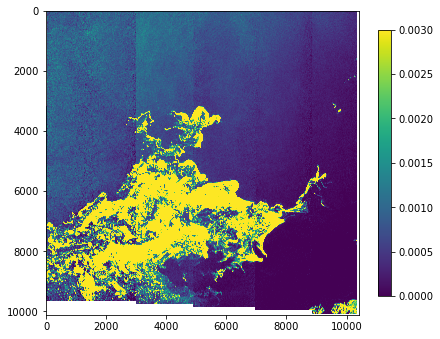

In [9]:
fig, ax = plt.subplots(figsize=(7,7))

img = ax.imshow(s1.sigma0_denoised, vmin=0., vmax=0.003)
fig.colorbar(img, ax=ax, shrink=0.7)

In [10]:
azimuth_avg = np.nanmean(s1.sigma0_denoised, axis=0)
azimuth_avg.shape

/tmp/ipykernel_4051/1194600524.py:1: RuntimeWarning: Mean of empty slice
  azimuth_avg = np.nanmean(s1.sigma0_denoised, axis=0)


(10399,)

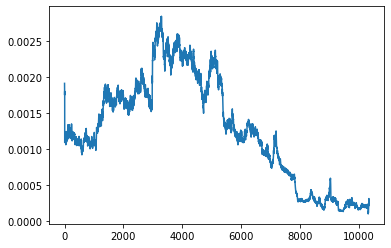

In [11]:
plt.plot(azimuth_avg)

In [12]:
s1.swath_scaling_factor

{'EW1': 1.6113740689039706,
 'EW2': 0.8198615042002766,
 'EW3': 0.9194332660480987,
 'EW4': 1.0938389767411143,
 'EW5': 1.102169601559076}

Use 'line' in block_noise_scaling_factors to access variance.  But the variance should probably be for denoised sigma 0

Draw swath boundaries

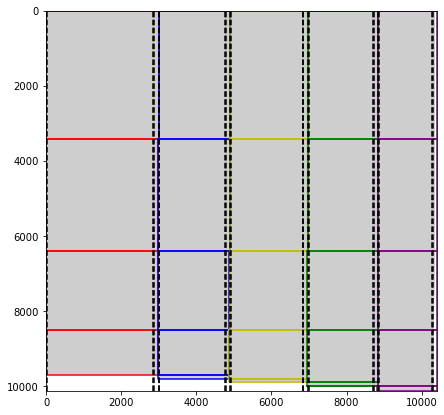

In [13]:
nazimuth, nrange = s1.sigma0.shape

fig, ax = plt.subplots(figsize=(7,7))
ax.set_xlim(0,nrange)
ax.set_ylim(nazimuth, 0)
ax.imshow(np.isfinite(s1.sigma0) * 0.3, vmin=0, vmax=1., cmap='Greys')

colors = ['r', 'b', 'y', 'g', 'purple']
for (swath_name, swath_bounds), color in zip(s1.swath_bounds['HV'].items(), colors):
    zipped = zip(
        swath_bounds['firstAzimuthLine'],
        swath_bounds['lastAzimuthLine'],
        swath_bounds['firstRangeSample'],
        swath_bounds['lastRangeSample'],
    )
    
    left_bound = max(swath_bounds['firstRangeSample']) + np.array([0,20])
    right_bound = min(swath_bounds['lastRangeSample']) + np.array([-120,-99])
    
    for fal, lal, frs, lrs in zipped:
        x = [frs, frs, lrs, lrs, frs]
        y = [fal, lal, lal, fal, fal]
        ax.plot(x, y, color)
    
    ax.axvline(left_bound[0], color='k', linestyle='--')
    ax.axvline(left_bound[1], color='k', linestyle='--')
    ax.axvline(right_bound[0], color='k', linestyle='--')
    ax.axvline(right_bound[1], color='k', linestyle='--')
    

In [14]:
sigma0_dn = s1.sigma0_denoised

## Calculate "homogeneity" of denoised image

This is in preparation for power balancing

In [15]:
def check_finite_lines(arr, min_lines=50, min_frac=.90):
    """Checks that arr block has at least min_lines of finite values
    
    :arr: 2D numpy array
    :min_lines: minimum number of lines
    :min_frac: minimum fraction of columns with at least min_lines
    
    :returns: boolean
    """
    is_min_lines = np.isfinite(arr).sum(axis=0) > min_lines
    return (is_min_lines.sum() / is_min_lines.shape) > min_frac

Calculate variance of blocks

In [16]:
window = 200

homogeneity = np.zeros(sigma0_dn.shape)
homogeneity[:, :] = np.nan

block_variance_list = []
for (swath_name, swath_bounds), color in zip(s1.swath_bounds['HV'].items(), colors):
    zipped = zip(
        swath_bounds['firstAzimuthLine'],
        swath_bounds['lastAzimuthLine'],
        swath_bounds['firstRangeSample'],
        swath_bounds['lastRangeSample'],
    )
    
    for fal, lal, frs, lrs in zipped:
        #arr = sigma0_dn[fal:lal+1, frs:lrs+1]
        for line in np.arange(fal, lal, window):
            arr = sigma0_dn[line:line+window, frs:lrs+1]
            if check_finite_lines(arr):
                block_variance = np.nanvar(arr)
                block_variance_list.append(block_variance)
                homogeneity[line:line+window, frs:lrs+1] = block_variance
            else: 
                homogeneity[line:line+window, frs:lrs+1] = np.nan


For the example used, only 38 blocks have a homogeneity below the threshold defined in Sun et al.  Need to see how this relates to other images.

In [17]:
(np.array(block_variance_list) < variance_threshold).sum()

38

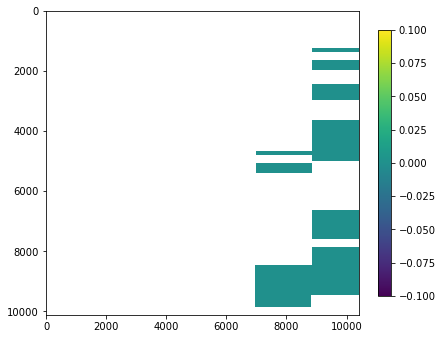

In [18]:
fig, ax = plt.subplots(figsize=(7,7))
ax.set_xlim(0,nrange)
ax.set_ylim(nazimuth, 0)
img = ax.imshow(np.where(homogeneity < variance_threshold, homogeneity, np.nan))
fig.colorbar(img, ax=ax, shrink=0.7)

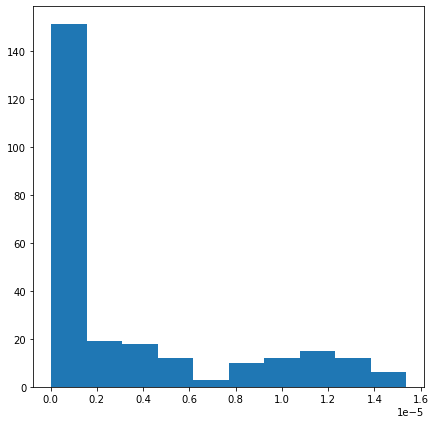

In [19]:
fig, ax = plt.subplots(figsize=(7,7))
ax.hist(block_variance_list);

Test check_finite_lines

In [20]:
nlines = 200
nsamples = 40

x = np.ones((nlines, nsamples))
x[-20:, :] = np.nan  # Set last 20 lines to nan
x[:, :20] = np.nan  # Set first 5 columns to nan

assert check_finite_lines(x)


AssertionError: 

In [ ]:
print(sigma0_dn.shape)
print(np.isfinite(sigma0_dn[0, :]).any())

## Playing with Power Balancing

- Set up some test arrays
- Calculate variance for blocks
- Try GLCM homogeneity

In [ ]:
nlines, nsamples = sigma0_dn.shape

right_power_bnd = max(s1.swath_bounds['HV']['EW2']['firstRangeSample']) + np.array([0,20])
left_power_bnd = min(s1.swath_bounds['HV']['EW1']['lastRangeSample']) + np.array([-120,-99])

right_block_power = get_block_average(sigma0_dn[:, right_power_bnd[0]: right_power_bnd[1]])
right_block_variance = get_block_variance(sigma0_dn[:, right_power_bnd[0]: right_power_bnd[1]])

left_block_power = get_block_average(sigma0_dn[:, left_power_bnd[0]: left_power_bnd[1]])
left_block_variance = get_block_variance(sigma0_dn[:, left_power_bnd[0]: left_power_bnd[1]])

power_balance = right_block_power[0] - left_block_power[0]
print(np.nanmean(power_balance))

xlimits = [0, nlines]

fig, ax = plt.subplots(3, 1, figsize=(12,9))
ax[0].plot(right_block_power[1], right_block_power[0], label='Right Power')
ax[0].plot(left_block_power[1], left_block_power[0], label='Left Power')
ax[0].set_xlim(xlimits)
ax[0].legend()

ax[1].plot(right_block_variance[1], right_block_variance[0], label='Right Variance')
ax[1].plot(left_block_variance[1], left_block_variance[0], label='Left Variance')
ax[1].set_xlim(xlimits)
ax[1].legend()

extent = [0, nlines, left_power_bnd[0]-500, right_power_bnd[1]+500]
ax[2].imshow(sigma0_dn[:, left_power_bnd[0]-500: right_power_bnd[1]+500].T, vmin=0, vmax=0.004,
            extent=extent)

## Apply Power Balance Factors

In [ ]:
pb_factor = {
    'EW1': 0.0,
    'EW2': 0.0007094111618628408,
    'EW3': 0.0,
    'EW4': 0.0,
    'EW5': 0.0
}

sigma0_dn_bal = np.zeros(sigma0_dn.shape)
sigma0_dn_bal[:, :] = np.nan

for (swath_name, swath_bounds), color in zip(s1.swath_bounds['HV'].items(), colors):
    zipped = zip(
        swath_bounds['firstAzimuthLine'],
        swath_bounds['lastAzimuthLine'],
        swath_bounds['firstRangeSample'],
        swath_bounds['lastRangeSample'],
    )
    
    for fal, lal, frs, lrs in zipped:
            sigma0_dn_bal[fal:lal+1, frs:lrs+1] = sigma0_dn[fal:lal+1, frs:lrs+1] + pb_factor[swath_name]

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,7))

ax[0].imshow(sigma0_dn, vmin=0, vmax=0.003)
ax[1].imshow(sigma0_dn_bal, vmin=0, vmax=0.003)

### Estimate Power Balancing Factor
The power balancing factor is an offset added to each subswath to remove jumps in power between sub-swaths.  $K^{0}_{pb,ssw}$ is the mean difference between average sigma0 for adjacent blocks.  See Eqs 10 and 11.

__The code below here contains functions to calculate power balancing__

In [70]:
def block_average(arr):
    '''Wrapper to get average for a given block'''
    with warnings.catch_warnings():
        warnings.filterwarnings(action='ignore', message='Mean of empty slice')
        arr_average = np.nanmean(arr)
    return arr_average
            

def block_variance(arr):
    """Wrapper to get variance for a given block"""
    with warnings.catch_warnings():
        warnings.filterwarnings(action='ignore', message='Degrees of freedom <= 0 for slice')
        arr_variance = np.nanvar(arr)
    return arr_variance


def get_block_average(arr, azimuth_window=200, minimum_lines=50):
    '''Calculate average sigma0 for azimuth blocks for power scaling'''
    nlines, nsamples = arr.shape
    
    window_start = np.arange(0, nlines, azimuth_window)
    window_end = window_start + azimuth_window
    window_end = np.where(window_end > nlines, nlines, window_end)
    
    lines = np.floor((window_start + window_end) / 2.)
    
    arr_average = []
    for w0, w1 in zip(window_start, window_end):
        if (w1 - w0 > minimum_lines):
            arr_average.append( block_average(arr[w0:w1, :]) )
            
    return np.array(arr_average), np.array(lines)
    
    
def get_block_variance(arr, azimuth_window=200, minimum_lines=50):
    '''Calculate variance sigma0 for azimuth blocks for power scaling'''
    nlines, nsamples = arr.shape
    
    window_start = np.arange(0, nlines, azimuth_window)
    window_end = window_start + azimuth_window
    window_end = np.where(window_end > nlines, nlines, window_end)
    
    lines = np.floor((window_start + window_end) / 2.)
    
    arr_average = []
    for w0, w1 in zip(window_start, window_end):
        if (w1 - w0 > minimum_lines):
            arr_average.append( block_variance(arr[w0:w1, :]) )
            
    return np.array(arr_average), np.array(lines)
    
    
def get_block_power(sigma0, swath_bounds, side='left', azimuth_window=200, minimum_lines=50):
    '''Calculate mean power for swath blocks following Sun et al, 2021.  Results are used to
    calculate power scaling factors.
    
    :sigma0: sigma nought array
    :swath_bounds: dict containing ranges of Azimuth lines and Range samples
    :side: str either 'left' or 'right' designating which side of swath boundary swath is on.
    :azimuth_window: number of azimuth lines in block
    :minimum_lines: minimum number of lines required for block mean to be calculated
    
    :returns: 1D numpy array containing mean power for blocks
    '''
    result = {
        'line': [],
        'power': [],
    }
    
    if side == 'left':
        bounds = min(swath_bounds['lastRangeSample']) + np.array([-120, -99])
    else:
        bounds = max(swath_bounds['firstRangeSample']) + np.array([0,20])
    
    block_sigma0, lines = get_block_average(sigma0[:, bounds[0]:bounds[1]],
                                            azimuth_window=azimuth_window,
                                            minimum_lines=minimum_lines)
    
    valid = np.where( (lines > min(swath_bounds['firstAzimuthLine'])) &
                      (lines <= max(swath_bounds['lastAzimuthLine'])) &
                      np.isfinite(block_sigma0) )[0]
        
    return block_sigma0[valid], lines[valid]

Calculate mean power for blocks on each side of swath boundaries.  Write to array of `dicts`, along with block variance.

In [15]:
band = 'HV'
swath_bounds = s1.swath_bounds[band]

block_power = []
swath_names = list(swath_bounds.keys())
for left_swath, right_swath in zip(swath_names[:-1], swath_names[1:]):
    
    left_block_power, left_lines = get_block_power(sigma0_dn, swath_bounds[left_swath], side='left')
    
    right_block_power, right_lines = get_block_power(sigma0_dn, swath_bounds[right_swath], side='right')
    
    block_power.append(
        {
            left_swath: {
                'block_sigma0': left_block_power,
                'lines': left_lines,
                'variance': np.array(s1.block_noise_scaling_factors[left_swath]['block_variance']),
                },
            right_swath: {
                'block_sigma0': right_block_power,
                'lines': right_lines,
                'variance': np.array(s1.block_noise_scaling_factors[right_swath]['block_variance']),
            }
        }
    )

For each swath-pair, find blocks with common lines.  If variance is less than threshold, calculate power_balance as difference between block power and average.  If not calculate mean power balance of all blocks.

Apply power scaling, and repeat.

In [29]:
block_power[0]['EW1']

{'block_sigma0': array([0.00094744, 0.00088815, 0.00094309, 0.00096846, 0.00078395,
        0.00080943, 0.00074455, 0.00081508, 0.00070668, 0.00076972,
        0.00082513, 0.00080257, 0.00078395, 0.00074699, 0.00071384,
        0.00076628, 0.00066921, 0.00201719, 0.00050513, 0.00060379,
        0.00048576, 0.00059253, 0.00038925, 0.00042528, 0.00044083,
        0.00038469, 0.00262391, 0.0019521 , 0.00224993, 0.00240795,
        0.00289853, 0.00462338, 0.0027032 , 0.00177651, 0.00154445,
        0.00216914, 0.00182679, 0.00306683, 0.00159995, 0.00480454,
        0.00701443, 0.00670371, 0.00508855, 0.00245082, 0.00255582,
        0.0010311 , 0.00084985, 0.00038416]),
 'lines': array([ 100.,  300.,  500.,  700.,  900., 1100., 1300., 1500., 1700.,
        1900., 2100., 2300., 2500., 2700., 2900., 3100., 3300., 3500.,
        3700., 3900., 4100., 4300., 4500., 4700., 4900., 5100., 5300.,
        5500., 5700., 5900., 6100., 6300., 6500., 6700., 6900., 7100.,
        7300., 7500., 7700., 7900

In [37]:
for counter, pair in enumerate(block_power):
    left_swath, right_swath = list(pair.keys())
    common_lines = list(set(pair[left_swath]['lines']).intersection(pair[right_swath]['lines']))
    #left_power = pair[left_swath]['block_sigma0'][common_lines]
    #left_variance = pair[left_swath]['variance'][common_lines]
    #right_power = pair[right_swath]['block_sigma0'][common_lines]
    #right_variance = pair[right_swath]['variance'][common_blocks]

    #power_balance = right_power - left_power

    print(left_swath, right_swath)
    print(common_lines)
    print(pair[left_swath]['lines'])
    break
    


EW1 EW2
[900.0, 4100.0, 7300.0, 2700.0, 5900.0, 9100.0, 1300.0, 4500.0, 7700.0, 5500.0, 3100.0, 6300.0, 9500.0, 1700.0, 4900.0, 8100.0, 300.0, 3500.0, 6700.0, 2100.0, 5300.0, 8500.0, 700.0, 3900.0, 7100.0, 2500.0, 5700.0, 8900.0, 1100.0, 4300.0, 7500.0, 2900.0, 6100.0, 9300.0, 1500.0, 4700.0, 7900.0, 100.0, 3300.0, 6500.0, 1900.0, 5100.0, 8300.0, 500.0, 3700.0, 6900.0, 8700.0, 2300.0]
[ 100.  300.  500.  700.  900. 1100. 1300. 1500. 1700. 1900. 2100. 2300.
 2500. 2700. 2900. 3100. 3300. 3500. 3700. 3900. 4100. 4300. 4500. 4700.
 4900. 5100. 5300. 5500. 5700. 5900. 6100. 6300. 6500. 6700. 6900. 7100.
 7300. 7500. 7700. 7900. 8100. 8300. 8500. 8700. 8900. 9100. 9300. 9500.]


Function to find indices for common lines, must be a more straight forward way!

In [40]:
def find_common_lines(left, right):
    """Returns indices for matching left and right lines"""
    common_lines = list(set(left).intersection(right))
    left_idx = np.nonzero( np.isin(left, commmon_lines) )
    right_idx = np.nonzero( np.isin(right, common_lines) )
    return left_id, right_idx

pair = block_power[0]
left_swath, right_swath = list(pair.values())
left_index, right_index = find_common_lines(left_swath, right_swath)

#np.nonzero(np.isin(right_swath['lines'], left_swath['lines']))

NameError: name 'commmon_lines' is not defined

In [55]:
a = np.array([1,2,3,4,5])
b = [2, 4, 5]
idx = np.nonzero(np.isin(a, b))
a[idx]

array([2, 4, 5])

In [23]:
for counter, pair in enumerate(block_power):
    swaths = list(pair.keys())
    
    #left_sigma0 = pair[swaths[0]]['lines']
    #right_sigma0 = pair[swaths[1]]['lines']
    #for lft, rgt in zip(left_sigma0, right_sigma0):
    #    print(lft, rgt)
    print(sorted(common_lines))
    break
    #for swath, params in pair.items():
    #    print(swath)
    #    for k, v in params.items():
    #        print(f'{k} {v.shape}')

[100.0, 300.0, 500.0, 700.0, 900.0, 1100.0, 1300.0, 1500.0, 1700.0, 1900.0, 2100.0, 2300.0, 2500.0, 2700.0, 2900.0, 3100.0, 3300.0, 3500.0, 3700.0, 3900.0, 4100.0, 4300.0, 4500.0, 4700.0, 4900.0, 5100.0, 5300.0, 5500.0, 5700.0, 5900.0, 6100.0, 6300.0, 6500.0, 6700.0, 6900.0, 7100.0, 7300.0, 7500.0, 7700.0, 7900.0, 8100.0, 8300.0, 8500.0, 8700.0, 8900.0, 9100.0, 9300.0, 9500.0]


In [25]:
for i, (pwr, line) in enumerate(zip(left_block_power, left_lines)):
    print(f'{line:7.0f} {pwr}')

    100 0.0009474428423158587
    300 0.0008881490567973148
    500 0.0009430858574261811
    700 0.0009684575339675745
    900 0.0007839531974509027
   1100 0.0008094297454855358
   1300 0.0007445536289703517
   1500 0.0008150788454545378
   1700 0.0007066771822816336
   1900 0.0007697249689484106
   2100 0.0008251256392229975
   2300 0.0008025697968523117
   2500 0.0007839529611355282
   2700 0.0007469867638895992
   2900 0.0007138356265088886
   3100 0.0007662841630469358
   3300 0.0006692065394480756
   3500 0.0020171900864156727
   3700 0.0005051289807771463
   3900 0.0006037941769175907
   4100 0.00048576391151441864
   4300 0.0005925319353403044
   4500 0.00038924534762328685
   4700 0.0004252806668365771
   4900 0.0004408299224845816
   5100 0.00038468958806451474
   5300 0.0026239120414272717
   5500 0.0019521036399925468
   5700 0.002249932877019457
   5900 0.0024079477739182504
   6100 0.0028985316270715806
   6300 0.00462337961153109
   6500 0.002703198845998237
   6700 0.0

In [67]:
print(s1.block_noise_scaling_factors['EW1']['line'])


[100.0, 300.0, 500.0, 700.0, 900.0, 1100.0, 1300.0, 1500.0, 1700.0, 1900.0, 2100.0, 2300.0, 2500.0, 2700.0, 2900.0, 3100.0, 3300.0, 3500.0, 3700.0, 3900.0, 4100.0, 4300.0, 4500.0, 4700.0, 4900.0, 5100.0, 5300.0, 5500.0, 5700.0, 5900.0, 6100.0, 6300.0, 6500.0, 6700.0, 6900.0, 7100.0, 7300.0, 7500.0, 7700.0, 7900.0, 8100.0, 8300.0, 8500.0, 8700.0, 8900.0, 9100.0, 9300.0, 9500.0]


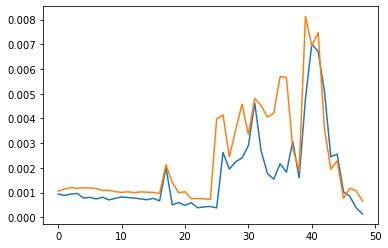

In [52]:
plt.plot(left_block_power)
plt.plot(right_block_power)

In [17]:
result = s1.block_noise_scaling_factors
for swath_left, swath_right in [('EW1','EW2'), ('EW2','EW3'), ('EW3','EW4'), ('EW4','EW5')]:
    a = set(result[swath_left]['line'])
    b = set(result[swath_right]['line'])
    print(len(a.intersection(b)))
    
#scaling in s1.block_noise_scaling_factors.items():
#    if 'EW' in swath_name:
#        print(len(scaling['line']))

48
49
49
50


In [ ]:
print(sigma0_dn_left.shape)
print(sigma0_dn_right.shape)

In [ ]:
def get_azimuth_block_average(arr, azimuth_window=200, minimum_lines=50):
    '''Calculate the average sigma0 for estimating power scaling factor
    
    TODO: Make a parameter, Make a parameter
    '''
    
    nline = arr.shape[0]
    window_start = np.arange(0, nline, azimuth_window)
    window_end = window_start + 200
    window_end = np.where(window_end > nline, nline, window_end)

    arr_block_avg = []
    for w0, w1 in zip(window_start, window_end):
        if w1 - w0 > minimum_lines:
            arr_block_avg.append(range_profile_average(arr[w0:w1]))
    return np.array(arr_block_avg)   

In [ ]:
sigma0_dn_left_block_avg = get_azimuth_block_average(sigma0_dn_left)
sigma0_dn_right_block_avg = get_azimuth_block_average(sigma0_dn_right)

In [ ]:
plt.plot(sigma0_dn_left_block_avg)
plt.plot(sigma0_dn_right_block_avg)

In [ ]:
len(s1.block_scaling_factors['EW1']['scaling_factor'])

In [ ]:
len(sigma0_dn_left_block_avg)